2026-02-22 14:50:47.039117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771771847.518839      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771771847.609300      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771771848.613824      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771771848.613867      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771771848.613870      24 computation_placer.cc:177] computation placer alr

✅ Mixed precision policy: mixed_float16
   (ViT-B/16 spec strictly maintained — no architectural changes)

GPU CONFIGURATION CHECK
✅ GPU Available: 2 device(s)
   - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
   - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
✅ Memory growth enabled

TensorFlow version : 2.19.0
Keras version      : 3.10.0

🎲 Global seed set to : 42

Configuration:
  Batch Size     : 32  (32 to prevent OOM; architecture unchanged)
  Epochs         : 30
  Image Size     : (250, 250)
  Num Classes    : 4  → BG | Healthy | WSSV | WSSV_BG
  Learning Rate  : 0.0001
  Case           : Case2_Aug_Aug_Aug

  Train dir      : /kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs/train
  Validation dir : /kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs/validation
  Test dir       : /kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs/test

DATA PREPARATION
Found 70

/tmp/ipykernel_24/2557882051.py:341: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
I0000 00:00:1771771889.334089      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771771889.340023      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_ViT_B16_Ensemble"

...


📐 Total parameters     : 90,839,876
📐 Trainable parameters : 88,578,308
✅ Architecture diagram saved: MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug_architecture.png

🚀 PHASE 1: Training with frozen MobileNetV2 backbone


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1771771931.737420      88 service.cc:152] XLA service 0x7c3a24002800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771771931.737474      88 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771771931.737482      88 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771771939.644446      88 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771771994.731876      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.3467 - loss: 1.5475
Epoch 1: val_accuracy improved from -inf to 0.61333, saving model to MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug_phase1_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.3470 - loss: 1.5468 - val_accuracy: 0.6133 - val_loss: 0.9598 - learning_rate: 1.0000e-04
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.4987 - loss: 1.1608
Epoch 2: val_accuracy improved from 0.61333 to 0.68000, saving model to MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug_phase1_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 125s 569ms/step - accuracy: 0.4988 - loss: 1.1607 - val_accuracy: 0.6800 - val_loss: 0.8004 - learning_rate: 1.0000e-04
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.5460 - loss: 1.0443
Epoch 3: val_accuracy did not improve from 0.68000
219/219 ━━━━━━━━━━━━━━━━━━━━ 119s 541ms/step - accuracy: 0.5461 - loss: 1.0442 - val_accuracy: 0.6567 - val_loss: 0.8124 - learning_rate: 1.0000e-04

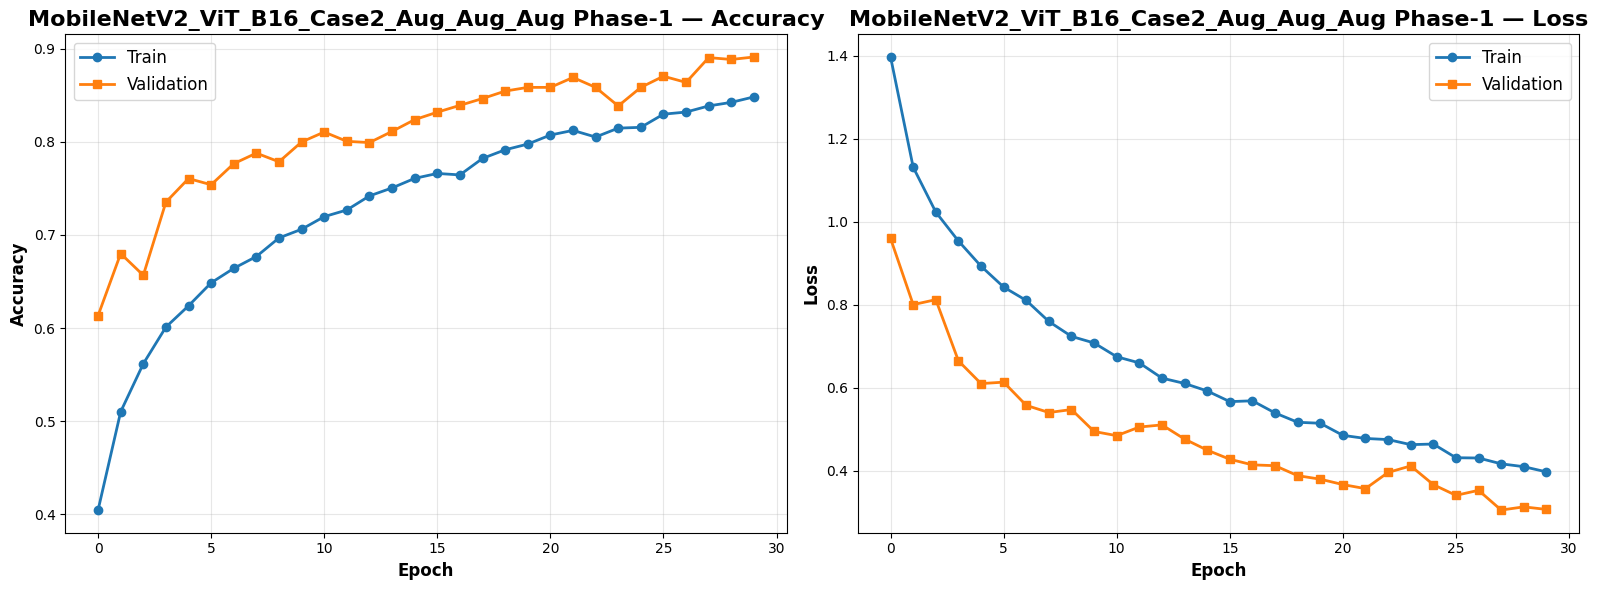


🔧 PHASE 2: Fine-tuning top 30 MobileNetV2 layers
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.6949 - loss: 0.8043
Epoch 1: val_accuracy improved from -inf to 0.84600, saving model to MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug_phase2_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 315s 972ms/step - accuracy: 0.6950 - loss: 0.8041 - val_accuracy: 0.8460 - val_loss: 0.4016 - learning_rate: 1.0000e-05
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.7466 - loss: 0.6670
Epoch 2: val_accuracy improved from 0.84600 to 0.84933, saving model to MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug_phase2_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 124s 563ms/step - accuracy: 0.7466 - loss: 0.6669 - val_accuracy: 0.8493 - val_loss: 0.3837 - learning_rate: 1.0000e-05
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.7534 - loss: 0.6031
Epoch 3: val_accuracy improved from 0.84933 to 0.86333, saving model to MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug_phase2_best.keras
219/219

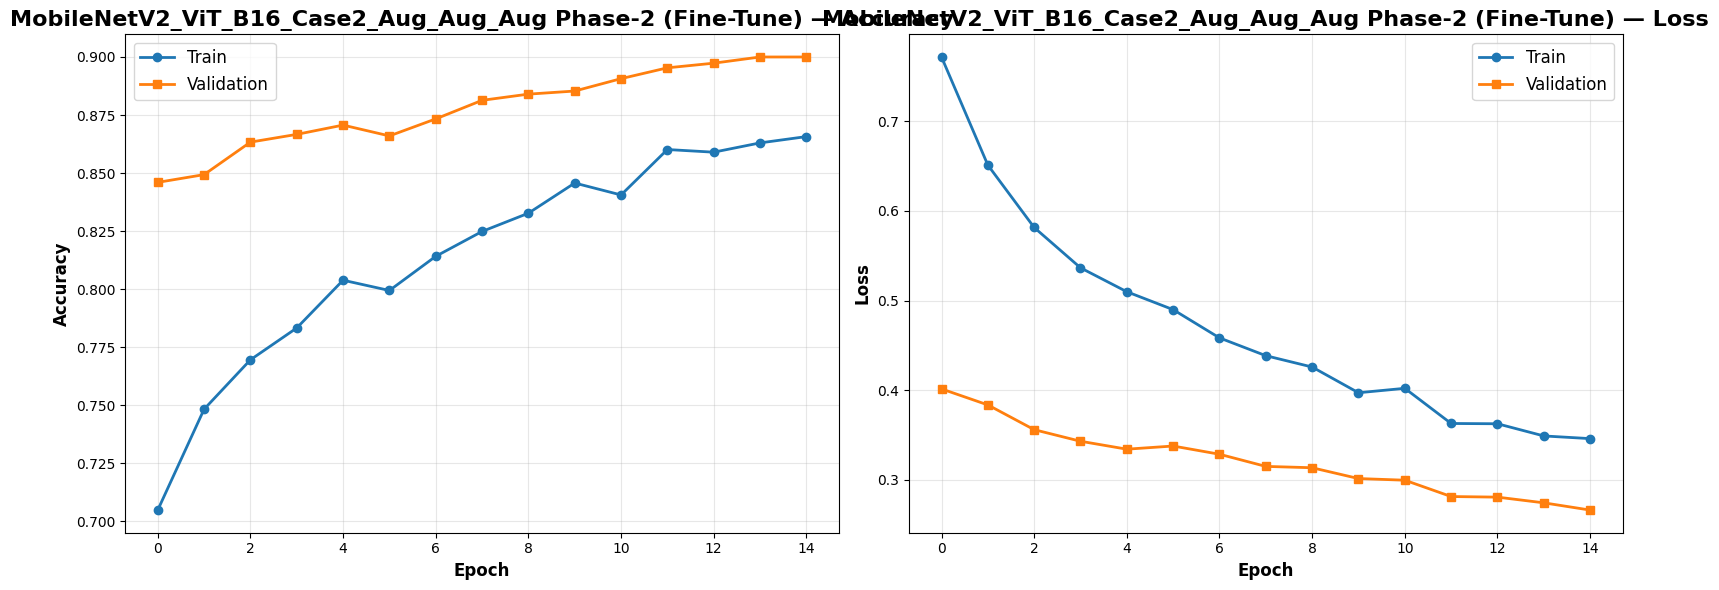

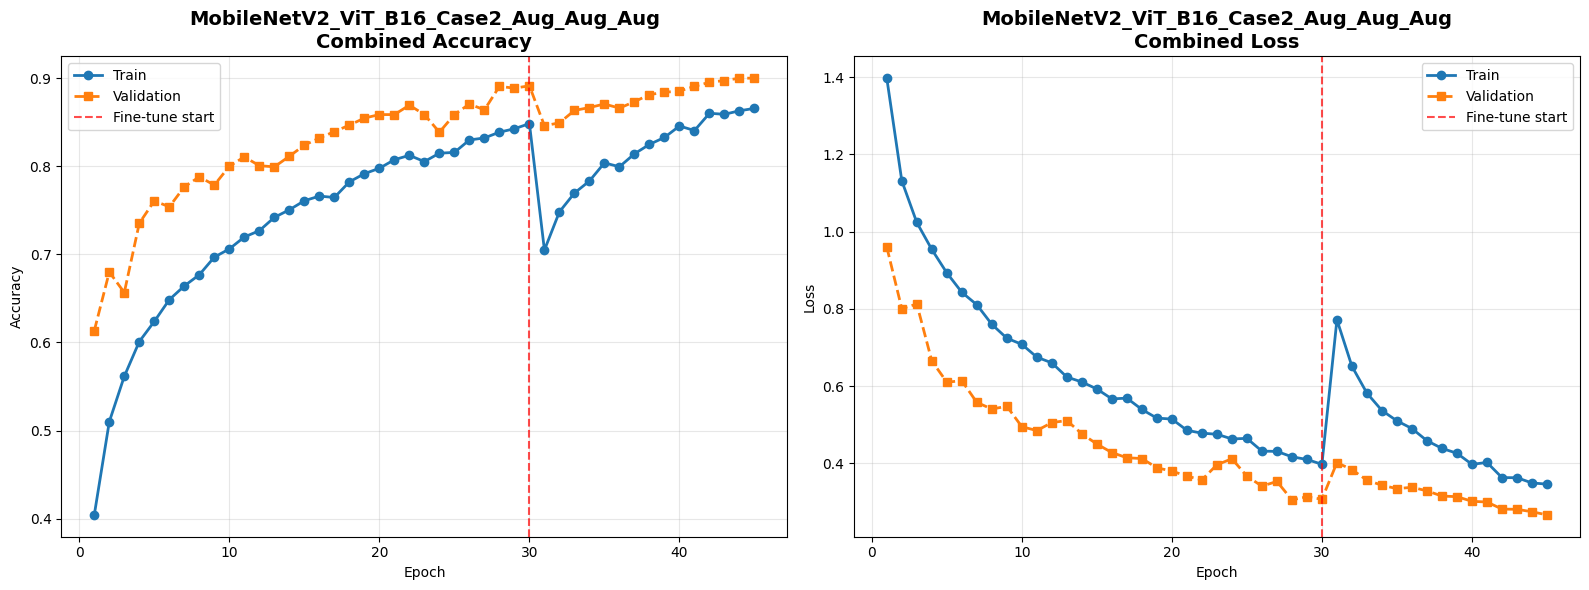


EVALUATION RESULTS ON TEST DATA — MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug

🔍 Generating predictions on test set...
47/47 ━━━━━━━━━━━━━━━━━━━━ 43s 606ms/step

📊 CLASSIFICATION PERFORMANCE METRICS (TEST SET):
                 Class  Precision   Recall  F1-Score  Support
                    BG   0.941520 0.858667  0.898187      375
               Healthy   0.856796 0.941333  0.897078      375
                  WSSV   0.902439 0.888000  0.895161      375
               WSSV_BG   0.915119 0.920000  0.917553      375
Overall (Weighted Avg)   0.903969 0.902000  0.901995     1500

🎯 Test Accuracy : 0.9020 (90.20%)

DETAILED CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

          BG     0.9415    0.8587    0.8982       375
     Healthy     0.8568    0.9413    0.8971       375
        WSSV     0.9024    0.8880    0.8952       375
     WSSV_BG     0.9151    0.9200    0.9176       375

    accuracy                         0.9020      1500
   macro avg     0

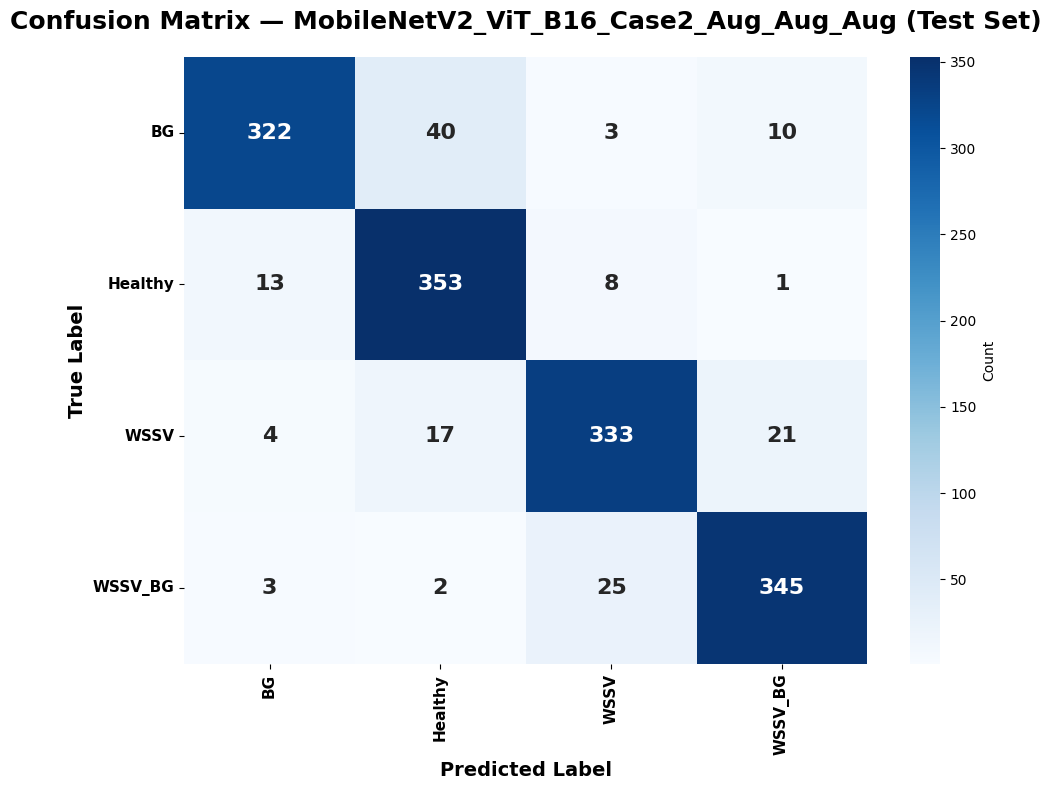


🎉 FINAL SUMMARY — MobileNetV2 + ViT-B/16 Ensemble
  Case             : Case2_Aug_Aug_Aug
  ViT-B/16 spec   : proj=768 | heads=12 | mlp=3072 | blocks=12
  Total Train Time : 1h 41m 1s
  Test Accuracy    : 90.20%
  Precision (W)    : 90.40%
  Recall (W)       : 90.20%
  F1-Score (W)     : 90.20%
📊 Results saved : MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug_results.csv
💾 Model saved   : MobileNetV2_ViT_B16_Case2_Aug_Aug_Aug_final.keras


In [1]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║         CNN-ViT HYBRID ENSEMBLE MODEL 2: MobileNetV2 + ViT-B/16            ║
║         Shrimp Disease Classification | Kaggle T4 GPU Optimized             ║
║                                                                              ║
║  ViT-B/16 STRICT SPEC:                                                       ║
║    projection_dim = 768  |  num_heads = 12                                  ║
║    mlp_dim = 3072        |  num_blocks = 12                                 ║
║                                                                              ║
║  OOM resolved via:  mixed_float16  +  batch_size=32                        ║
║  Architecture unchanged from ViT-B/16 paper specification                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATASET CASES — uncomment exactly ONE block:
  Case 1 → Raw/train  | Raw/val  | Raw/test        (Orig | Orig | Orig)
  Case 2 → Aug/train  | Aug/val  | Aug/test        (Aug  | Aug  | Aug )
  Case 3 → Raw/train  | Raw/val  | Aug/test        (Orig | Orig | Aug )

Classes: BG | Healthy | WSSV | WSSV_BG  (NUM_CLASSES = 4)
"""

import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)

# ============================================================
# MIXED PRECISION — ONLY memory fix used; ViT-B/16 is untouched
# ============================================================
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision policy: mixed_float16")
print("   (ViT-B/16 spec strictly maintained — no architectural changes)")

# ============================================================
# CASE SELECTION — uncomment exactly ONE block
# ============================================================

# ── CASE 1: Original | Original | Original ──────────────────
# RAW            = '/kaggle/input/elsevier-disease-shrimp-data/Raw_Train_test_Validation'
# train_dir      = os.path.join(RAW, 'train')
# validation_dir = os.path.join(RAW, 'validation')
# test_dir       = os.path.join(RAW, 'test')
# CASE_NAME      = 'Case1_Orig_Orig_Orig'

# ── CASE 2: Augmented | Augmented | Augmented ───────────────
AUG            = '/kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs'
train_dir      = os.path.join(AUG, 'train')
validation_dir = os.path.join(AUG, 'validation')
test_dir       = os.path.join(AUG, 'test')
CASE_NAME      = 'Case2_Aug_Aug_Aug'

# ── CASE 3: Original | Original | Augmented ─────────────────
# RAW            = '/kaggle/input/elsevier-disease-shrimp-data/Raw_Train_test_Validation'
# AUG            = '/kaggle/input/elsevier-disease-shrimp-data/2_Conventional_augmented_2500_ttvs'
# train_dir      = os.path.join(RAW, 'train')
# validation_dir = os.path.join(RAW, 'validation')
# test_dir       = os.path.join(AUG, 'test')
# CASE_NAME      = 'Case3_Orig_Orig_Aug'

# ============================================================
# GPU CONFIGURATION
# ============================================================
print("\n" + "=" * 80)
print("GPU CONFIGURATION CHECK")
print("=" * 80)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"   - {gpu}")
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ Memory growth enabled")
else:
    print("⚠️  No GPU detected! Running on CPU")
print(f"\nTensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

# ============================================================
# GLOBAL CONFIGURATION
# ============================================================
SEED          = 42
BATCH_SIZE    = 32
EPOCHS        = 30
IMG_SIZE      = (250, 250)
NUM_CLASSES   = 4
LEARNING_RATE = 0.0001
MODEL_NAME    = f'MobileNetV2_ViT_B16_{CASE_NAME}'

random.seed(SEED);  np.random.seed(SEED);  tf.random.set_seed(SEED)

print(f"\n🎲 Global seed set to : {SEED}")
print(f"\nConfiguration:")
print(f"  Batch Size     : {BATCH_SIZE}  (32 to prevent OOM; architecture unchanged)")
print(f"  Epochs         : {EPOCHS}")
print(f"  Image Size     : {IMG_SIZE}")
print(f"  Num Classes    : {NUM_CLASSES}  → BG | Healthy | WSSV | WSSV_BG")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Case           : {CASE_NAME}")
print(f"\n  Train dir      : {train_dir}")
print(f"  Validation dir : {validation_dir}")
print(f"  Test dir       : {test_dir}")

# ============================================================
# DATA PREPARATION
# ============================================================
print("\n" + "=" * 80)
print("DATA PREPARATION")
print("=" * 80)

train_datagen    = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_generator = val_test_datagen.flow_from_directory(
    validation_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print(f"\n✓ Data generators created")
print(f"  Training samples   : {train_generator.samples}")
print(f"  Validation samples : {val_generator.samples}")
print(f"  Test samples       : {test_generator.samples}")
print(f"  Classes            : {class_names}")

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def format_time(seconds):
    h, rem = divmod(int(seconds), 3600)
    m, s   = divmod(rem, 60)
    if h: return f"{h}h {m}m {s}s"
    if m: return f"{m}m {s}s"
    return f"{s}s"


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].plot(history.history['accuracy'],     lw=2, label='Train',      marker='o')
    axes[0].plot(history.history['val_accuracy'], lw=2, label='Validation', marker='s')
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['loss'],     lw=2, label='Train',      marker='o')
    axes[1].plot(history.history['val_loss'], lw=2, label='Validation', marker='s')
    axes[1].set_title(f'{model_name} — Loss', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=12); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def evaluate_model(model, test_gen, model_name):
    print(f"\n{'=' * 80}")
    print(f"EVALUATION RESULTS ON TEST DATA — {model_name}")
    print("=" * 80)
    test_gen.reset()
    print("\n🔍 Generating predictions on test set...")
    predictions = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes
    cn     = list(test_gen.class_indices.keys())

    accuracy = np.mean(y_pred == y_true)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(NUM_CLASSES))

    metrics_df = pd.DataFrame({
        'Class': cn, 'Precision': precision,
        'Recall': recall, 'F1-Score': f1, 'Support': support
    })
    wp, wr, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    overall = pd.DataFrame({
        'Class': ['Overall (Weighted Avg)'], 'Precision': [wp],
        'Recall': [wr], 'F1-Score': [wf1], 'Support': [len(y_true)]
    })
    metrics_df = pd.concat([metrics_df, overall], ignore_index=True)

    print("\n📊 CLASSIFICATION PERFORMANCE METRICS (TEST SET):")
    print("=" * 80)
    print(metrics_df.to_string(index=False))
    print("=" * 80)
    print(f"\n🎯 Test Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)")
    print("\n" + "=" * 80)
    print("DETAILED CLASSIFICATION REPORT (TEST SET)")
    print("=" * 80)
    print(classification_report(y_true, y_pred, target_names=cn, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cn, yticklabels=cn,
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 16, 'weight': 'bold'})
    plt.title(f'Confusion Matrix — {model_name} (Test Set)',
              fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label',      fontsize=14, fontweight='bold')
    plt.xticks(fontsize=11, fontweight='bold', rotation=90)
    plt.yticks(fontsize=11, fontweight='bold', rotation=0)
    plt.tight_layout(); plt.show()
    return accuracy, wp, wr, wf1


def plot_combined_history(h1, h2, model_name, phase1_len):
    keys   = ('accuracy', 'val_accuracy', 'loss', 'val_loss')
    merged = {k: h1.history.get(k, []) + h2.history.get(k, []) for k in keys}
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    e = range(1, len(merged['accuracy']) + 1)
    axes[0].plot(e, merged['accuracy'],     'o-',  lw=2, label='Train')
    axes[0].plot(e, merged['val_accuracy'], 's--', lw=2, label='Validation')
    axes[0].axvline(x=phase1_len, color='red', ls='--', alpha=0.7, label='Fine-tune start')
    axes[0].set_title(f'{model_name}\nCombined Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(e, merged['loss'],     'o-',  lw=2, label='Train')
    axes[1].plot(e, merged['val_loss'], 's--', lw=2, label='Validation')
    axes[1].axvline(x=phase1_len, color='red', ls='--', alpha=0.7, label='Fine-tune start')
    axes[1].set_title(f'{model_name}\nCombined Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{MODEL_NAME}_combined_history.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# PatchPositionEmbedding — XLA / gradient-safe
# ============================================================
class PatchPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches    = num_patches
        self.projection_dim = projection_dim

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name='pos_embedding',
            shape=(1, self.num_patches, self.projection_dim),
            initializer='random_normal', trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        return x + self.pos_emb

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches,
                    'projection_dim': self.projection_dim})
        return cfg


# ============================================================
# ViT-B/16 — STRICT PAPER SPECIFICATION
#   projection_dim=768 | num_heads=12 | mlp_dim=3072 | num_blocks=12
# ============================================================
def create_vit_b16(input_shape,
                   projection_dim=768,
                   num_heads=12,
                   mlp_dim=3072,
                   num_blocks=12,
                   dropout=0.1,
                   name='ViT_B16'):
    patch_size  = 16
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)

    inputs = layers.Input(shape=input_shape, name=f'{name}_input')

    patches = layers.Conv2D(
        projection_dim, kernel_size=patch_size, strides=patch_size,
        padding='valid', name=f'{name}_patch_conv'
    )(inputs)
    patches = layers.Reshape(
        (num_patches, projection_dim), name=f'{name}_patch_reshape'
    )(patches)

    x = PatchPositionEmbedding(
        num_patches, projection_dim, name=f'{name}_pos_emb'
    )(patches)

    for i in range(num_blocks):
        x1   = layers.LayerNormalization(epsilon=1e-6, name=f'{name}_ln1_{i}')(x)
        attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim // num_heads,
            dropout=dropout,
            name=f'{name}_mha_{i}'
        )(x1, x1)
        x2   = layers.Add(name=f'{name}_add1_{i}')([attn, x])
        x3   = layers.LayerNormalization(epsilon=1e-6, name=f'{name}_ln2_{i}')(x2)
        x3   = layers.Dense(mlp_dim, activation='gelu',
                            name=f'{name}_mlp_fc1_{i}')(x3)
        x3   = layers.Dropout(dropout, name=f'{name}_mlp_drop1_{i}')(x3)
        x3   = layers.Dense(projection_dim,
                            name=f'{name}_mlp_fc2_{i}')(x3)
        x3   = layers.Dropout(dropout, name=f'{name}_mlp_drop2_{i}')(x3)
        x    = layers.Add(name=f'{name}_add2_{i}')([x3, x2])

    x = layers.LayerNormalization(epsilon=1e-6, name=f'{name}_ln_final')(x)
    x = layers.GlobalAveragePooling1D(name=f'{name}_gap')(x)
    return Model(inputs=inputs, outputs=x, name=name)


# ============================================================
# ENSEMBLE: MobileNetV2 (CNN frontend) + ViT-B/16 (Transformer backend)
#
# MobileNetV2 → GAP → 1280-d
# ViT-B/16    → GAP →  768-d
# Concatenate →       2048-d → Dense head → 4-class Softmax
# ============================================================
def build_mobilenetv2_vit_ensemble(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape, name='input')

    # CNN Frontend: MobileNetV2 (ImageNet pretrained, frozen phase-1)
    mobilenet = MobileNetV2(
        include_top=False, weights='imagenet',
        input_shape=input_shape, pooling='avg'
    )
    mobilenet.trainable = False
    cnn_out = mobilenet(inputs, training=False)     # (batch, 1280)

    # Transformer Backend: ViT-B/16 (trained from scratch)
    vit     = create_vit_b16(input_shape, name='ViT_B16')
    vit_out = vit(inputs)                           # (batch, 768)

    # Feature Fusion
    fused = layers.Concatenate(name='feature_fusion')([cnn_out, vit_out])
    # fused shape: (batch, 2048)

    # Classification Head
    x = layers.Dense(1024, name='fc1')(fused)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)

    x = layers.Dense(512, name='fc2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.4, name='drop2')(x)

    x = layers.Dense(256, name='fc3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.Dropout(0.3, name='drop3')(x)

    outputs = layers.Dense(
        num_classes, activation='softmax',
        dtype='float32', name='output'
    )(x)

    return Model(inputs=inputs, outputs=outputs,
                 name='MobileNetV2_ViT_B16_Ensemble'), mobilenet


# ============================================================
# BUILD MODEL
# ============================================================
print("\n" + "=" * 80)
print("BUILDING MODEL: MobileNetV2 (CNN) + ViT-B/16 (Transformer)")
print("ViT-B/16 spec: projection_dim=768 | num_heads=12 | mlp_dim=3072 | num_blocks=12")
print("=" * 80)

input_shape = IMG_SIZE + (3,)
model, mobilenet_base = build_mobilenetv2_vit_ensemble(input_shape, NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n📐 Total parameters     : {total_params:,}")
print(f"📐 Trainable parameters : {trainable_params:,}")

try:
    tf.keras.utils.plot_model(
        model, to_file=f'{MODEL_NAME}_architecture.png',
        show_shapes=True, show_layer_names=True,
        dpi=96, expand_nested=False
    )
    print(f"✅ Architecture diagram saved: {MODEL_NAME}_architecture.png")
except Exception as e:
    print(f"⚠️  Could not save diagram: {e}")

# ============================================================
# PHASE 1 — Frozen MobileNetV2, train ViT-B/16 + head
# ============================================================
print("\n" + "=" * 80)
print("🚀 PHASE 1: Training with frozen MobileNetV2 backbone")
print("=" * 80)

callbacks_p1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1, min_delta=0.001
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{MODEL_NAME}_phase1_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

start_p1   = time.time()
history_p1 = model.fit(
    train_generator, epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_p1, verbose=1
)
phase1_time = time.time() - start_p1
print(f"\n✅ Phase 1 complete — {format_time(phase1_time)}")
plot_training_history(history_p1, f'{MODEL_NAME} Phase-1')

# ============================================================
# PHASE 2 — Fine-tune top 30 MobileNetV2 layers
# ============================================================
print("\n" + "=" * 80)
print("🔧 PHASE 2: Fine-tuning top 30 MobileNetV2 layers")
print("=" * 80)

mobilenet_base.trainable = True
FT_FROM = len(mobilenet_base.layers) - 30
for layer in mobilenet_base.layers[:FT_FROM]:
    layer.trainable = False
for layer in mobilenet_base.layers[FT_FROM:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-8, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{MODEL_NAME}_phase2_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

start_p2   = time.time()
history_p2 = model.fit(
    train_generator, epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_p2, verbose=1
)
phase2_time = time.time() - start_p2
print(f"\n✅ Phase 2 complete — {format_time(phase2_time)}")
plot_training_history(history_p2, f'{MODEL_NAME} Phase-2 (Fine-Tune)')

plot_combined_history(history_p1, history_p2, MODEL_NAME,
                      len(history_p1.history['accuracy']))

# ============================================================
# EVALUATION
# ============================================================
total_time = phase1_time + phase2_time
acc, prec, rec, f1 = evaluate_model(model, test_generator, MODEL_NAME)

# ============================================================
# FINAL SUMMARY & SAVE
# ============================================================
print("\n" + "=" * 80)
print("🎉 FINAL SUMMARY — MobileNetV2 + ViT-B/16 Ensemble")
print("=" * 80)
print(f"  Case             : {CASE_NAME}")
print(f"  ViT-B/16 spec   : proj=768 | heads=12 | mlp=3072 | blocks=12")
print(f"  Total Train Time : {format_time(total_time)}")
print(f"  Test Accuracy    : {acc * 100:.2f}%")
print(f"  Precision (W)    : {prec * 100:.2f}%")
print(f"  Recall (W)       : {rec * 100:.2f}%")
print(f"  F1-Score (W)     : {f1 * 100:.2f}%")
print("=" * 80)

results = pd.DataFrame([{
    'Model': MODEL_NAME, 'Case': CASE_NAME,
    'ViT_spec': 'proj=768,heads=12,mlp=3072,blocks=12',
    'Test Accuracy': acc, 'Precision': prec,
    'Recall': rec, 'F1-Score': f1,
    'Training Time': format_time(total_time)
}])
results.to_csv(f'{MODEL_NAME}_results.csv', index=False)
print(f"📊 Results saved : {MODEL_NAME}_results.csv")

model.save(f'{MODEL_NAME}_final.keras')
print(f"💾 Model saved   : {MODEL_NAME}_final.keras")